<a href="https://colab.research.google.com/github/albaras236-del/KOPI-GIT/blob/main/Bank_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3

# 1. Load dataset Bank Churn langsung dari repository data Kaggle
url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
df_bank = pd.read_csv(url)

# 2. Buat database SQLite & simpan ke tabel
conn = sqlite3.connect(":memory:")
df_bank.to_sql("tabel_churn", conn, index=False)

print("✅ Dataset Bank Churn berhasil dimuat!")
print(f"Total baris data: {len(df_bank)} nasabah\n")
df_bank.head(3)

✅ Dataset Bank Churn berhasil dimuat!
Total baris data: 10000 nasabah



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [5]:
query_Churn = """
Select
Geography,
Gender,
Count (*) As total_nasabah,
sum(Exited) as Jumlah_churn,
round(Avg(Exited)* 100,2) as Churn_rate_percent,
round(Avg(Balance),2) as rata_rata_saldo
from  tabel_churn
group by Geography, Gender
order by churn_rate_percent Desc
"""
df_analyst = pd.read_sql_query(query_Churn, conn)
df_analyst

,Geography,Gender,total_nasabah,Jumlah_churn,Churn_rate_percent,rata_rata_saldo
0,Germany,Female,1193,448,37.55,119145.97
1,Germany,Male,1316,366,27.81,120259.67
2,Spain,Female,1089,231,21.21,59862.09
3,France,Female,2261,460,20.34,60322.67
4,Spain,Male,1388,182,13.11,63352.83
5,France,Male,2753,350,12.71,63546.28


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


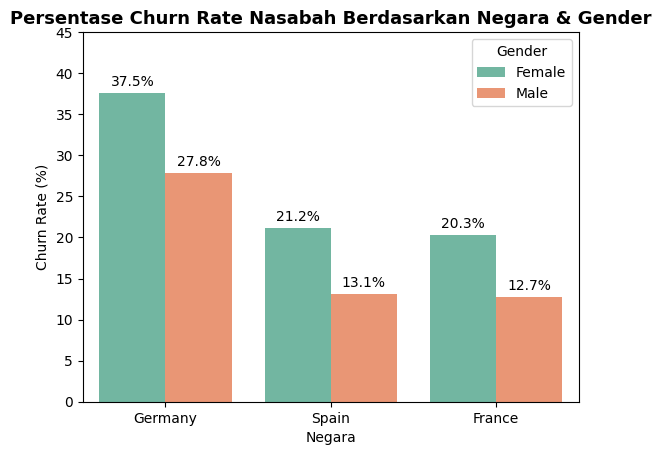

In [12]:
ax = sns.barplot(
    data=df_analyst,
    x="Geography",
    y="Churn_rate_percent",
    hue="Gender",
    palette="Set2",
)

# 3. Judul dan Label
plt.title(
    "Persentase Churn Rate Nasabah Berdasarkan Negara & Gender",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Negara")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 45)

# 4. Tambahkan persentase di atas SEMUA batang (menggunakan bar_label)
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f%%", padding=3)

# 5. Tampilkan
plt.show()

In [14]:
query_produk = """
select
NumOfProducts,
count(*) as total_nasabah,
sum(exited) as jumlah_churn,
round(avg(exited)*100,2) as churn_rate_percent
from tabel_churn
group by NumOfProducts
order by churn_rate_percent desc
"""
df_produk = pd.read_sql_query(query_produk, conn)
df_produk

,NumOfProducts,total_nasabah,jumlah_churn,churn_rate_percent
0,4,60,60,100.00
1,3,266,220,82.71
2,1,5084,1409,27.71
3,2,4590,348,7.58


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3792/1949797304.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


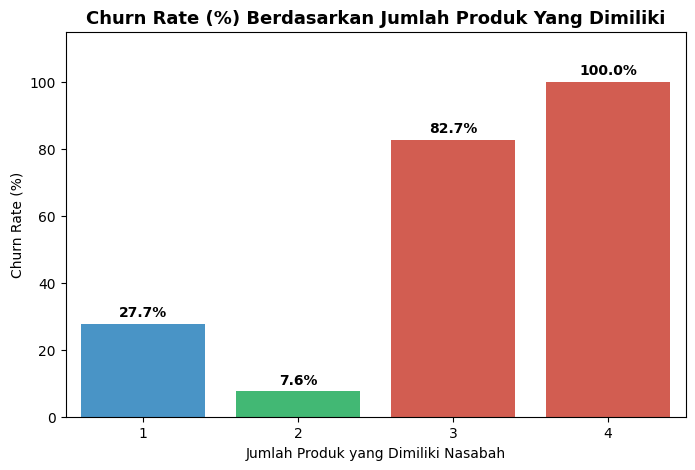

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Load dataset & buat koneksi SQLite (Menjamin 'conn' selalu ada)
url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
df_bank = pd.read_csv(url)

conn = sqlite3.connect(":memory:")
df_bank.to_sql("tabel_churn", conn, index=False)

# 2. Jalankan kueri SQL untuk df_produk
query_produk = """
SELECT
    NumOfProducts,
    COUNT(*) AS total_nasabah,
    SUM(Exited) AS jumlah_churn,
    ROUND(AVG(Exited) * 100, 2) AS churn_rate_percent
FROM tabel_churn
GROUP BY NumOfProducts
ORDER BY NumOfProducts ASC
"""
df_produk = pd.read_sql_query(query_produk, conn)

# 3. Set ukuran kanvas grafik
plt.figure(figsize=(8, 5))

# 4. Warna khusus: Hijau = Aman (2 produk), Merah = Risiko (3 & 4 produk)
colors = [
    "#3498db" if x == 1 else "#2ecc71" if x == 2 else "#e74c3c"
    for x in df_produk["NumOfProducts"]
]

# 5. Buat Bar Chart
ax = sns.barplot(
    data=df_produk,
    x="NumOfProducts",
    y="churn_rate_percent",
    palette=colors,
)

# 6. Judul dan Label
plt.title(
    "Churn Rate (%) Berdasarkan Jumlah Produk Yang Dimiliki",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Jumlah Produk yang Dimiliki Nasabah")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 115)

# 7. Tambahkan angka persentase di atas setiap batang
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")

# 8. Tampilkan Grafik
plt.show()

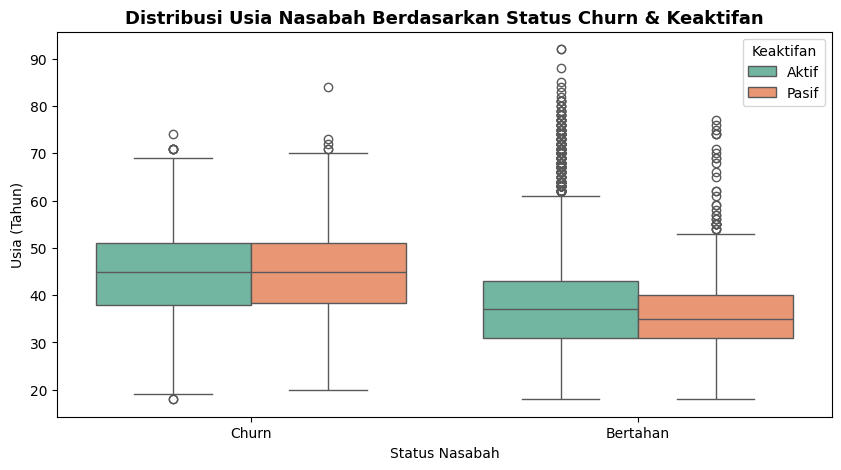

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ambil data Usia, Status Active, dan Exited dari SQLite
query_age = """
SELECT Age, IsActiveMember, Exited
FROM tabel_churn
"""
df_age = pd.read_sql_query(query_age, conn)

# 2. Mapping label agar mudah dibaca di grafik
df_age["Status Churn"] = df_age["Exited"].map({0: "Bertahan", 1: "Churn"})
df_age["Status Keaktifan"] = df_age["IsActiveMember"].map(
    {0: "Pasif", 1: "Aktif"}
)

# 3. Set ukuran kanvas
plt.figure(figsize=(10, 5))

# 4. Buat Boxplot Distribusi Usia berdasarkan Status Churn & Keaktifan
sns.boxplot(
    data=df_age,
    x="Status Churn",
    y="Age",
    hue="Status Keaktifan",
    palette="Set2",
)

plt.title(
    "Distribusi Usia Nasabah Berdasarkan Status Churn & Keaktifan",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Status Nasabah")
plt.ylabel("Usia (Tahun)")
plt.legend(title="Keaktifan", loc="upper right")

plt.show()

In [1]:
import pandas as pd
import sqlite3

# 1. Load Data & Inisialisasi Database SQLite
url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
df_bank = pd.read_csv(url)

conn = sqlite3.connect(":memory:")
df_bank.to_sql("tabel_churn", conn, index=False)

# 2. Kueri SQL Kompleks: Segmentasi Risiko Nasabah
query_segmentasi = """
SELECT
    CASE
        WHEN NumOfProducts >= 3 THEN 'Critical Risk (Too Many Products)'
        WHEN Age >= 45 AND IsActiveMember = 0 THEN 'High Risk (Inactive Senior)'
        WHEN Geography = 'Germany' AND Gender = 'Female' THEN 'Medium-High Risk (German Female)'
        ELSE 'Low Risk (Loyal Segment)'
    END AS segmen_risiko,
    COUNT(*) AS total_nasabah,
    SUM(Exited) AS jumlah_churn,
    ROUND(AVG(Exited) * 100, 2) AS churn_rate_percent,
    ROUND(AVG(Balance), 2) AS rata_rata_saldo
FROM tabel_churn
GROUP BY segmen_risiko
ORDER BY churn_rate_percent DESC
"""

df_segmentasi = pd.read_sql_query(query_segmentasi, conn)
df_segmentasi

,segmen_risiko,total_nasabah,jumlah_churn,churn_rate_percent,rata_rata_saldo
0,Critical Risk (Too Many Products),326,280,85.89,78821.79
1,High Risk (Inactive Senior),922,593,64.32,84313.15
2,Medium-High Risk (German Female),953,256,26.86,118822.14
3,Low Risk (Loyal Segment),7799,908,11.64,70289.62


/tmp/ipykernel_3812/2715819801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


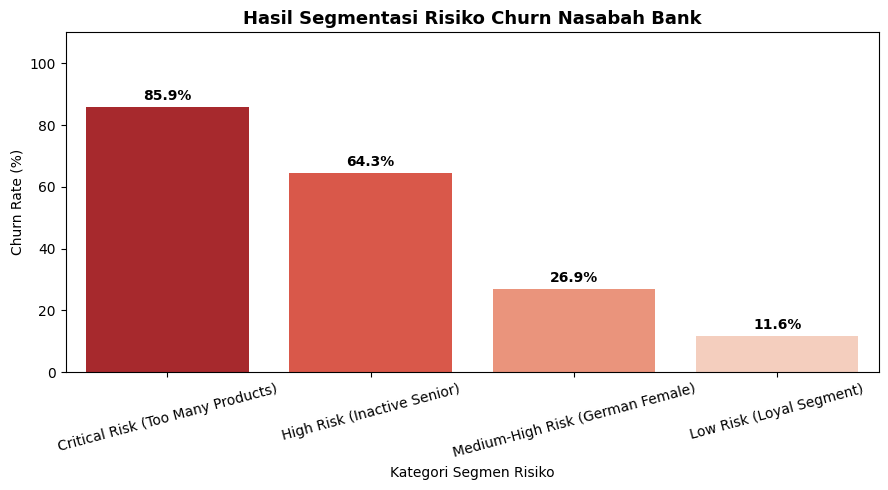

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# Plot Bar Chart Segmen Risiko
ax = sns.barplot(
    data=df_segmentasi,
    x="segmen_risiko",
    y="churn_rate_percent",
    palette="Reds_r",
)

plt.title(
    "Hasil Segmentasi Risiko Churn Nasabah Bank", fontsize=13, fontweight="bold"
)
plt.xlabel("Kategori Segmen Risiko")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.ylim(0, 110)

# Tambahkan label persentase di atas batang
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f%%", padding=3, fontweight="bold")

plt.tight_layout()
plt.show()

Bank Customer Churn & Retention Strategy key business insight

In [3]:
%%writefile README.md
# 🏦 Bank Customer Churn Analysis

## 📌 Executive Summary
Project ini bertujuan untuk mengidentifikasi pola nasabah yang berisiko melakukan *churn* (menutup rekening) menggunakan SQL (SQLite) dan Python.

## 🔑 Key Insights
1. **Over-Product Trap:** Nasabah yang memiliki 3 produk atau lebih mengalami *churn rate* hingga **82,7% – 100%**.
2. **Demographic Risk:** Nasabah wanita (*Female*) di cabang **Germany** merupakan segmen paling rawan dengan *churn rate* **37,5%** dan rata-rata saldo tertinggi (~119.000).
3. **Product Sweet Spot:** Nasabah dengan **2 produk** adalah kelompok paling loyal (*churn rate* hanya 7,6%).

## 🛠️ Tech Stack
- **Language:** Python
- **Libraries:** Pandas, Seaborn, Matplotlib
- **Database:** SQLite3
- **Environment:** Google Colab

## 🚀 Recommendations
- Tinjau ulang struktur biaya administrasi pada paket 3–4 produk.
- Lakukan program retensi proaktif untuk nasabah pasif berusia $\ge 45$ tahun.

Writing README.md
